In [1]:
# Importing the libraries
# Load the data from Email_spam.csv

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler  # Import StandardScaler

In [7]:
# Importing the dataset
df = pd.read_csv('./dataset/Email_spam.csv')

print(df['spam'].value_counts())
# Convert the structured NumPy array to a pandas DataFrame
print(df.head(5))

spam
0    3554
1     367
Name: count, dtype: int64
   row  spam  to_multiple  from  cc  sent_email              time  image  \
0    1     0            0     1   0           0  31/12/2011 22:16      0   
1    2     0            0     1   0           0  31/12/2011 23:03      0   
2    3     0            0     1   0           0     1/1/2012 1:09      0   
3    4     0            0     1   0           0     1/1/2012 2:00      0   
4    5     0            0     1   0           0     1/1/2012 2:04      0   

   attach  dollar  ... viagra  password  num_char  line_breaks  format  \
0       0       0  ...      0         0    11.370          202       1   
1       0       0  ...      0         0    10.504          202       1   
2       0       0  ...      0         0    13.256          255       1   
3       0       0  ...      0         2     1.231           29       0   
4       0       0  ...      0         2     1.091           25       0   

   re_subj  exclaim_subj  urgent_subj  exclaim_

In [177]:
#get dummies / onehot encoding

df1 = df.drop(columns=['row','time'])

df_getDummy = pd.get_dummies(df1)

print(df_getDummy.head(5))

   spam  to_multiple  from  cc  sent_email  image  attach  dollar  inherit  \
0     0            0     1   0           0      0       0       0        0   
1     0            0     1   0           0      0       0       0        0   
2     0            0     1   0           0      0       0       0        0   
3     0            0     1   0           0      0       0       0        0   
4     0            0     1   0           0      0       0       0        0   

   viagra  ...  format  re_subj  exclaim_subj  urgent_subj  exclaim_mess  \
0       0  ...       1        0             0            0             0   
1       0  ...       1        0             0            0             1   
2       0  ...       1        0             0            0            48   
3       0  ...       0        0             0            0             1   
4       0  ...       0        0             0            0             1   

   winner_no  winner_yes  number_big  number_none  number_small  
0       

In [195]:
# Drop spam column and convert dataframe into numpy n-d array format

X = df_getdummy.drop(['spam'],axis=1).to_numpy()

##scale Xscaler = StandardScaler
X = scaler.fit_transform(X)

# Set spam column as target label Y

Y = df_getdummy['spam'].to_numpy()

print(X.shape)
print(Y.shape)

(3921, 3721)
(3921,)


In [197]:
# Fitting Logistic Regression to the training set

classifier1 = LogisticRegression(solver='liblinear', random_state = 0)
classifier1.fit(X, Y)

LogisticRegression(random_state=0, solver='liblinear')

In [201]:
import sklearn.metrics as metrics

y_pred=classifier1.predict(X)

accuracy = metrics.accuracy_score(Y, y_pred)
print("train accuracy: %.2f." %accuracy)

precision = metrics.precision_score(Y, y_pred)
print("train precision: %.2f." %precision)

recall = metrics.recall_score(Y, y_pred)
print("train recall: %.2f." %recall)

print(y_pred[:100])

train accuracy: 1.00.
train precision: 1.00.
train recall: 1.00.
[0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


3553 1 1 366


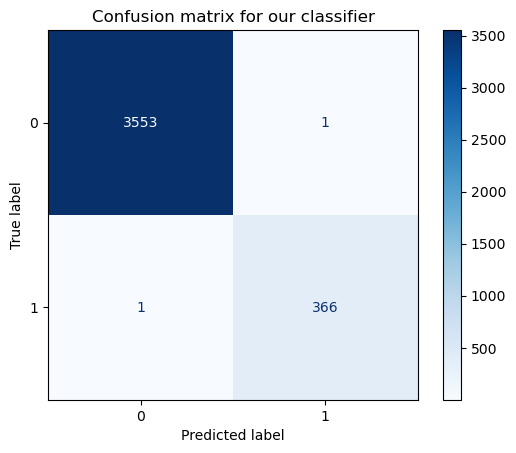

In [205]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#Counts of true negatives, false positives, false negatives and true positives
tn, fp, fn, tp = confusion_matrix(Y, y_pred).ravel()
print(tn, fp, fn, tp)

#Plot the confusion matrix
cm = confusion_matrix(Y, y_pred)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier1.classes_)
disp.plot(cmap=plt.cm.Blues)  # You can set normalize to 'true' or 'all' if needed
plt.title('Confusion matrix for our classifier')
plt.show()

In [207]:
# Print classification report
print(classification_report(Y, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3554
           1       1.00      1.00      1.00       367

    accuracy                           1.00      3921
   macro avg       1.00      1.00      1.00      3921
weighted avg       1.00      1.00      1.00      3921

